# Linear Regression

In this lab, you will implement linear regression with one variable to predict profits for a restaurant franchise.


# Outline
- [ 1 - Packages ](#1)
- [ 2 - Linear regression with one variable ](#2)
  - [ 2.1 Problem Statement](#2.1)
  - [ 2.2  Dataset](#2.2)
  - [ 2.3 Refresher on linear regression](#2.3)
  - [ 2.4  Compute loss](#2.4)
    - [ Exercise 1](#ex01)
  - [ 2.5 Gradient descent ](#2.5)
    - [ Exercise 2](#ex02)
  - [ 2.6 Learning parameters using batch gradient descent ](#2.6)
- [ 3 - Ordinary Least Squares (OLS) Process ](#3)
    - [ Exercise 3](#ex03)


<a name="1"></a>
## 1 - Packages 

First, let's run the cell below to import all the packages that you will need during this assignment.
- [numpy](www.numpy.org) is the fundamental package for working with matrices in Python.
- [matplotlib](http://matplotlib.org) is a famous library to plot graphs in Python.
- ``utils.py`` contains helper functions for this assignment. You do not need to modify code in this file.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

## 2 -  Problem Statement

Suppose you are the CEO of a restaurant franchise and are considering different cities for opening a new outlet.
- You would like to expand your business to cities that may give your restaurant higher profits.
- The chain already has restaurants in various cities and you have data for profits and populations from the cities.
- You also have data on cities that are candidates for a new restaurant. 
    - For these cities, you have the city population.
    
Can you use the data to help you identify which cities may potentially give your business higher profits?

## 3 - Dataset

You will start by loading the dataset for this task. 
- The `load_data()` function shown below loads the data into variables `x_train` and `y_train`
  - `x_train` is the population of a city
  - `y_train` is the profit of a restaurant in that city. A negative value for profit indicates a loss.   
  - Both `X_train` and `y_train` are numpy arrays.

In [2]:
# load the dataset
x_train, y_train = load_data()

#### View the variables
Before starting on any task, it is useful to get more familiar with your dataset.  
- A good place to start is to just print out each variable and see what it contains.

The code below prints the variable `x_train` and the type of the variable.

In [3]:
# print x_train
print("Type of x_train:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5]) 

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]


`x_train` is a numpy array that contains decimal values that are all greater than zero.
- These values represent the city population times 10,000
- For example, 6.1101 means that the population for that city is 61,101
  
Now, let's print `y_train`

In [4]:
# print y_train
print("Type of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5])  

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


Similarly, `y_train` is a numpy array that has decimal values, some negative, some positive.
- These represent your restaurant's average monthly profits in each city, in units of \$10,000.
  - For example, 17.592 represents \$175,920 in average monthly profits for that city.
  - -2.6807 represents -\$26,807 in average monthly loss for that city.

#### Check the dimensions of your variables

Another useful way to get familiar with your data is to view its dimensions.

Please print the shape of `x_train` and `y_train` and see how many training examples you have in your dataset.

In [5]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


The city population array has 97 data points, and the monthly average profits also has 97 data points. These are NumPy 1D arrays.

#### Visualize your data

It is often useful to understand the data by visualizing it. 
- For this dataset, you can use a scatter plot to visualize the data, since it has only two properties to plot (profit and population). 
- Many other problems that you will encounter in real life have more than two properties (for example, population, average household income, monthly profits, monthly sales).When you have more than two properties, you can still use a scatter plot to see the relationship between each pair of properties.


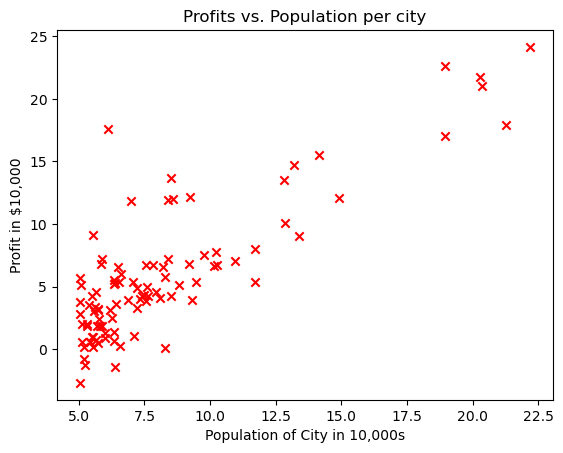

In [6]:
# Create a scatter plot of the data. To change the markers to red "x",
# we used the 'marker' and 'c' parameters
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

Your goal is to build a linear regression model to fit this data.
- With this model, you can then input a new city's population, and have the model estimate your restaurant's potential monthly profits for that city.

<a name="4"></a>
## 4 - Refresher on linear regression

In this practice lab, you will fit the linear regression parameters to your dataset.
- The model function for linear regression, which is a function that maps from `x` (city population) to `y` (your restaurant's monthly profit for that city) is represented as 
    $$y = \theta_0 x_0 + \theta_1 x_1$$
    

**Note:** This is mathematically equivalent to the familiar slope-intercept equation $y = wx + b$. In this matrix-friendly notation, $\theta_1$ represents the weight $w$, and the term $\theta_0 x_0$ represents the bias $b$. We intentionally set $x_0 = 1$ to make it easier to calculate and represent the operations as matrices, leading us to an Ordinary Least Squares (OLS) process.

- To train a linear regression model, you want to find the best parameters $(\theta_0, \theta_1)$ that fit your dataset.  

    - To compare how one choice of parameters is better or worse than another choice, you can evaluate it with a loss function $J(\theta_0, \theta_1)$
    - The choice of parameters that fits your data the best is the one that has the smallest loss $J(\theta_0, \theta_1)$.


- To find the values that gets the smallest possible loss $J$, you can use a method called **gradient descent**. 
  - With each step of gradient descent, your parameters come closer to the optimal values that will achieve the lowest loss $J$.
  

- The trained linear regression model can then take the input feature $x$ (city population) and output a prediction (predicted monthly profit for a restaurant in that city).

<a name="5"></a>
## 5 - Compute loss

Gradient descent involves repeated steps to adjust the value of your parameters $(\theta_0, \theta_1)$ to gradually get a smaller and smaller loss $J(\theta_0, \theta_1)$.
- At each step of gradient descent, it will be helpful for you to monitor your progress by computing the loss $J(\theta_0, \theta_1)$ as $(\theta_0, \theta_1)$ gets updated. 
- In this section, you will implement a function to calculate $J(\theta_0, \theta_1)$ so that you can check the progress of your gradient descent implementation.

#### Loss function
As you may recall from the lecture, for one variable, the loss function for linear regression $J(\theta_0, \theta_1)$ is defined as

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{\theta_0, \theta_1}(x^{(i)}) - y^{(i)})^2$$

- You can think of $f_{\theta_0, \theta_1}(x^{(i)})$ as the model's prediction of your restaurant's profit, as opposed to $y^{(i)}$, which is the actual profit that is recorded in the data.
- $m$ is the number of training examples in the dataset

#### Model prediction

- For linear regression with one variable, the prediction of the model $f_{\theta_0, \theta_1}$ for an example $x^{(i)}$ is representented as:

$$ f_{\theta_0, \theta_1}(x^{(i)}) = \theta_0 x_0^{(i)} + \theta_1 x_1^{(i)}$$

This is the equation for a line, where we set $x_0^{(i)} = 1$.

#### Implementation

Please complete the `compute_loss()` function below to compute the loss $J(\theta_0, \theta_1)$.

<a name="ex01"></a>
### Exercise 1

Complete the `compute_loss` below to:

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example 
    $$
    f_{\theta_0, \theta_1}(x^{(i)}) =  \theta_0 (1) + \theta_1 x_1^{(i)}
    $$
   
    * The loss for that example  $$loss^{(i)} =  (f_{\theta_0, \theta_1} - y^{(i)})^2$$
    

* Return the total loss over all examples
$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} loss^{(i)}$$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [16]:
# UNQ_C1
# GRADED FUNCTION: compute_loss

def compute_loss(x, y, theta1, theta0): 
    """
    Computes the loss function for linear regression.
    
    Args:
        x (ndarray): Shape (m,) Input to the model (Population of cities) 
        y (ndarray): Shape (m,) Label (Actual profits for the cities)
        theta1, theta0 (scalar): Parameters of the model
    
    Returns
        total_loss (float): The loss of using theta1, theta0 as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    # You need to return this variable correctly
    total_loss = 0

    #calculate the total loss using the formula of the cost function for linear regression
    ''' START CODE HERE '''
    
    for i in range(m):
        f = theta0 + theta1 * x[i]
        loss = (f - y[i]) ** 2
        total_loss += loss
    total_loss /= m * 2
    
    ''' END CODE HERE '''

    return total_loss

You can check if your implementation was correct by running the following test code:

In [17]:
# Compute loss with some initial values for paramaters theta1, theta0
initial_theta1 = 2
initial_theta0 = 1

loss  = compute_loss(x_train, y_train, initial_theta1, initial_theta0)


print(type(loss))
print(f'loss at initial thetas: {loss:.3f}')

# Public tests
from public_tests import *
compute_loss_test(compute_loss)

<class 'numpy.float64'>
loss at initial thetas: 75.203
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>Loss at initial thetas:<b> 75.203 </td> 
  </tr>
</table>

<a name="6"></a>
## 6 - Gradient descent (Not required!)

In this section, you will implement the gradient for parameters $\theta_0, \theta_1$ for linear regression. 

As described in the lecture videos, the gradient descent algorithm is:

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & \phantom {0000} \theta_0 := \theta_0 -  \alpha \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0} \newline       \; & \phantom {0000} \theta_1 := \theta_1 -  \alpha \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1} \tag{1}  \; & 
\newline & \rbrace\end{align*}$$

where, parameters $\theta_0, \theta_1$ are both updated simultaniously and where  
$$
\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\theta_0, \theta_1}(x^{(i)}) - y^{(i)})x_0^{(i)} \tag{2}
$$
$$
\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\theta_0, \theta_1}(x^{(i)}) -y^{(i)})x_1^{(i)} \tag{3}
$$
* m is the number of training examples in the dataset
* Remember we set $x_0^{(i)} = 1$
* $f_{\theta_0, \theta_1}(x^{(i)})$ is the model's prediction, while $y^{(i)}$, is the target value


You will implement a function called `compute_gradient` which calculates $\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1}$, $\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0}$ 

<a name="ex02"></a>
### Exercise 2 (Not required!)

Please complete the `compute_gradient` function to:

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example 
    $$
    f_{\theta_0, \theta_1}(x^{(i)}) =  \theta_0 (1) + \theta_1 x_1^{(i)} 
    $$
   
    * The gradient for the parameters $\theta_0, \theta_1$ from that example 
        $$
        \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0}^{(i)}  =  (f_{\theta_0, \theta_1}(x^{(i)}) - y^{(i)}) (1) 
        $$
        $$
        \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1}^{(i)}  =  (f_{\theta_0, \theta_1}(x^{(i)}) -y^{(i)})x_1^{(i)} 
        $$
    

* Return the total gradient update from all the examples
    $$
    \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0}^{(i)}
    $$
    
    $$
    \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1}^{(i)} 
    $$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [21]:
# UNQ_C2
# GRADED FUNCTION: compute_gradient
def compute_gradient(x, y, theta1, theta0): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      theta1, theta0 (scalar): Parameters of the model  
    Returns
      dj_dtheta1 (scalar): The gradient of the loss w.r.t. the parameters theta1
      dj_dtheta0 (scalar): The gradient of the loss w.r.t. the parameter theta0     
     """
    
    # Number of training examples
    m = x.shape[0]
    
    # You need to return the following variables correctly
    dj_dtheta1 = 0
    dj_dtheta0 = 0
    
    ### START CODE HERE ### 
    for i in range(m):
        f_theta = theta0 * 1 + theta1 * x[i]
        dj_dtheta0 += (f_theta - y[i]) * 1
        dj_dtheta1 += (f_theta - y[i]) * x[i]
    dj_dtheta1 /= m
    dj_dtheta0 /= m
    
    ### END CODE HERE ### 
        
    return dj_dtheta1, dj_dtheta0

<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
       
    * You can represent a summation operator eg: $h = \sum\limits_{i = 0}^{m-1} 2i$ in code as follows:
     ```python 
    h = 0
    for i in range(m):
        h = h + 2*i
    ```
    
    * In this case, you can iterate over all the examples in `x` using a for loop and for each example, keep adding the gradient from that example to the variables `dj_dtheta1` and `dj_dtheta0` which are initialized outside the loop. 

   * Then, you can return `dj_dtheta1` and `dj_dtheta0` both divided by `m`.    
    <details>
          <summary><font size="2" color="darkblue"><b> Click for more hints</b></font></summary>
        
    * Here's how you can structure the overall implementation for this function
    ```python 
    def compute_gradient(x, y, theta1, theta0): 
        """
        Computes the gradient for linear regression 
        Args:
          x (ndarray): Shape (m,) Input to the model (Population of cities) 
          y (ndarray): Shape (m,) Label (Actual profits for the cities)
          theta1, theta0 (scalar): Parameters of the model  
        Returns
          dj_dtheta1 (scalar): The gradient of the loss w.r.t. the parameters theta1
          dj_dtheta0 (scalar): The gradient of the loss w.r.t. the parameter theta0     
         """
    
        # Number of training examples
        m = x.shape[0]
    
        # You need to return the following variables correctly
        dj_dtheta1 = 0
        dj_dtheta0 = 0
    
        ### START CODE HERE ### 
        # Loop over examples
        for i in range(m):  
            # Your code here to get prediction f_theta for the ith example
            f_theta = 
            
            # Your code here to get the gradient for theta1 from the ith example 
            dj_dtheta1_i = 
        
            # Your code here to get the gradient for theta0 from the ith example 
            dj_dtheta0_i = 
     
            # Update dj_dtheta0 : In Python, a += 1  is the same as a = a + 1
            dj_dtheta0 += dj_dtheta0_i
        
            # Update dj_dtheta1
            dj_dtheta1 += dj_dtheta1_i
    
        # Divide both dj_dtheta1 and dj_dtheta0 by m
        dj_dtheta1 = dj_dtheta1 / m
        dj_dtheta0 = dj_dtheta0 / m
        ### END CODE HERE ### 
        
        return dj_dtheta1, dj_dtheta0
    ```
    
    If you're still stuck, you can check the hints presented below to figure out how to calculate `f_theta` and `loss`.
    
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate f_theta</b></font></summary>
           &emsp; &emsp; You did this in the previous exercise! For scalars $a$, $b$ and $c$ (<code>x[i]</code>, <code>theta1</code> and <code>theta0</code> are all scalars), you can calculate the equation $h = ab + c$ in code as <code>h = a * b + c</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate f</b></font></summary>
               &emsp; &emsp; You can compute f_theta as <code>f_theta = theta0 * 1 + theta1 * x[i] </code>
           </details>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate dj_dtheta1_i</b></font></summary>
           &emsp; &emsp; For scalars $a$, $b$ and $c$ (<code>f_theta</code>, <code>y[i]</code> and <code>x[i]</code> are all scalars), you can calculate the equation $h = (a - b)c$ in code as <code>h = (a-b)*c</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; More hints to calculate f</b></font></summary>
               &emsp; &emsp; You can compute dj_dtheta1_i as <code>dj_dtheta1_i = (f_theta - y[i]) * x[i] </code>
           </details>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>Hint to calculate dj_dtheta0_i</b></font></summary>
             &emsp; &emsp; You can compute dj_dtheta0_i as <code> dj_dtheta0_i = (f_theta - y[i]) * 1 </code>
    </details>
        
    </details>

</details>

    


Run the cells below to check your implementation of the `compute_gradient` function with two different initializations of the parameters $\theta_1$,$\theta_0$.

In [22]:
# Compute and display gradient with theta initialized to zeroes
initial_theta1 = 0
initial_theta0 = 0

tmp_dj_dtheta1, tmp_dj_dtheta0 = compute_gradient(x_train, y_train, initial_theta1, initial_theta0)
print('Gradient at initial thetas (zeros):', tmp_dj_dtheta1, tmp_dj_dtheta0)

compute_gradient_test(compute_gradient)

Gradient at initial thetas (zeros): -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


Now let's run the gradient descent algorithm implemented above on our dataset.

**Expected Output**:
<table>
  <tr>
    <td> <b>Gradient at initial thetas (zeros)<b></td>
    <td> -65.32884975 -5.83913505154639</td> 
  </tr>
</table>

In [23]:
# Compute and display loss and gradient with non-zero thetas
test_theta1 = 0.2
test_theta0 = 0.2
tmp_dj_dtheta1, tmp_dj_dtheta0 = compute_gradient(x_train, y_train, test_theta1, test_theta0)

print('Gradient at test thetas:', tmp_dj_dtheta1, tmp_dj_dtheta0)

Gradient at test thetas: -47.41610118114435 -4.007175051546391


**Expected Output**:
<table>
  <tr>
    <td> <b>Gradient at test thetas<b></td>
    <td> -47.41610118 -4.007175051546391</td> 
  </tr>
</table>

<a name="2.6"></a>
### 2.6 Learning parameters using batch gradient descent 

You will now find the optimal parameters of a linear regression model by using batch gradient descent. Recall batch refers to running all the examples in one iteration.
- You don't need to implement anything for this part. Simply run the cells below. 

- A good way to verify that gradient descent is working correctly is to look
at the value of $J(\theta_0, \theta_1)$ and check that it is decreasing with each step. 

- Assuming you have implemented the gradient and computed the loss correctly and you have an appropriate value for the learning rate alpha, $J(\theta_0, \theta_1)$ should never increase and should converge to a steady value by the end of the algorithm.

In [26]:
def gradient_descent(x, y, theta1_in, theta0_in, loss_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      theta1_in, theta0_in : (scalar) Initial values of parameters of the model
      loss_function: function to compute loss
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      theta1 : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      theta0 : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(x)
    
    # An array to store loss J and theta1's at each iteration — primarily for graphing later
    J_history = []
    theta1_history = []
    theta1 = copy.deepcopy(theta1_in)  #avoid modifying global theta1 within function
    theta0 = theta0_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dtheta1, dj_dtheta0 = gradient_function(x, y, theta1, theta0)  

        # Update Parameters using theta1, theta0, alpha and gradient
        theta1 = theta1 - alpha * dj_dtheta1               
        theta0 = theta0 - alpha * dj_dtheta0               

        # Save loss J at each iteration
        if i<100000:      # prevent resource exhaustion 
            loss =  loss_function(x, y, theta1, theta0)
            J_history.append(loss)

        # Print loss every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            theta1_history.append(theta1)
            print(f"Iteration {i:4}: loss {float(J_history[-1]):8.2f}   ")
        
    return theta1, theta0, J_history, theta1_history #return thetas and J,theta1 history for graphing

Now let's run the gradient descent algorithm above to learn the parameters for our dataset.

In [27]:
# initialize fitting parameters
initial_theta1 = 0.
initial_theta0 = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

theta1, theta0, _, _ = gradient_descent(x_train ,y_train, initial_theta1, initial_theta0, 
                     compute_loss, compute_gradient, alpha, iterations)
print("theta1, theta0 found by gradient descent:", theta1, theta0)

Iteration    0: loss     6.74   
Iteration  150: loss     5.31   
Iteration  300: loss     4.96   
Iteration  450: loss     4.76   
Iteration  600: loss     4.64   
Iteration  750: loss     4.57   
Iteration  900: loss     4.53   
Iteration 1050: loss     4.51   
Iteration 1200: loss     4.50   
Iteration 1350: loss     4.49   
theta1, theta0 found by gradient descent: 1.166362350335582 -3.63029143940436


**Expected Output**:
<table>
  <tr>
    <td> <b> thetas found by gradient descent<b></td>
    <td> 1.16636235 -3.63029143940436</td> 
  </tr>
</table>

We will now use the final parameters from gradient descent to plot the linear fit. 

Recall that we can get the prediction for a single example $f(x^{(i)})= \theta_0 (1) + \theta_1 x_1^{(i)}$. 

To calculate the predictions on the entire dataset, we can loop through all the training examples and calculate the prediction for each example. This is shown in the code block below.

In [28]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = theta0 * 1 + theta1 * x_train[i]

We will now plot the predicted values to see the linear fit.

Text(0.5, 0, 'Population of City in 10,000s')

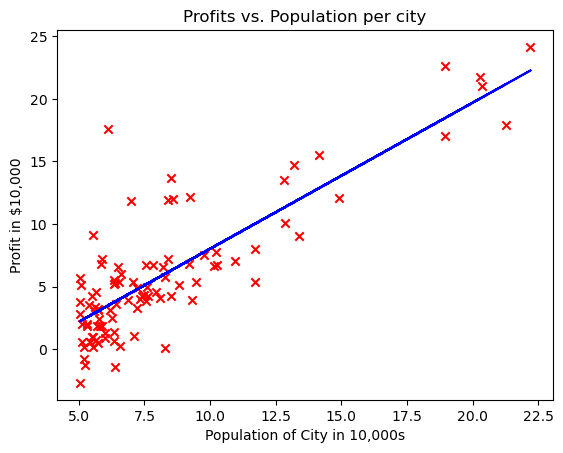

In [29]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')

Your final values of parameters can also be used to make predictions on profits. Let's predict what the profit would be in areas of 35,000 and 70,000 people. 

- The model takes in population of a city in 10,000s as input. 

- Therefore, 35,000 people can be translated into an input to the model as `np.array([3.5])`

- Similarly, 70,000 people can be translated into an input to the model as `np.array([7.])`


In [31]:
predict1 = theta0 * 1 + theta1 * 3.5
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = theta0 * 1 + theta1 * 7.0
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


**Expected Output**:
<table>
  <tr>
    <td> <b> For population = 35,000, we predict a profit of<b></td>
    <td> $4519.77 </td> 
  </tr>
  
  <tr>
    <td> <b> For population = 70,000, we predict a profit of<b></td>
    <td> $45342.45 </td> 
  </tr>
</table>

<a name="3"></a>
## 3 - Ordinary Least Squares (OLS) Process

While gradient descent is an excellent algorithm for minimizing the loss function iteratively, linear regression also has a closed-form mathematical solution that finds the optimal parameters directly. This is called the Normal Equation or the Ordinary Least Squares (OLS) process.

Recall our matrix-friendly equation: $$\hat y = X \theta$$

By representing our feature data as a matrix $X$ (where the first column is all 1s representing our $x_0$ intercept multiplier) and our parameters as a vector $\theta$, we can calculate the optimal $\theta$ directly using the following formula:

$$\theta = (X^T X)^{-1} X^T y$$


<a name="ex03"></a>
### Exercise 3

Use the OLS formula to find the optimal parameters directly. We have provided the code to add the $x_0 = 1$ intercept term to the $X$ matrix below.

In [34]:
from numpy.linalg import inv

# Add a column of ones to x_train for the intercept term (x0 = 1)
X_matrix = np.c_[np.ones((m, 1)), x_train]
y_matrix = y_train.reshape(-1, 1)


# Implement the Normal Equation to calculate the optimal theta parameters without iteration
# use @ for matrix multiplication , .T to caculate the transpose of a matrix and inv() to calculate the inverse of a matrix
'''START CODE HERE '''

theta = inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y_matrix

''' END CODE HERE '''

print(f"Theta found by OLS: theta_0 (bias) = {theta[0][0]:.4f}, theta_1 (weight) = {theta[1][0]:.4f}")
print(f"Compare to Gradient Descent: theta_0 = {theta0:.4f}, theta_1 = {theta1:.4f}")

Theta found by OLS: theta_0 (bias) = -3.8958, theta_1 (weight) = 1.1930
Compare to Gradient Descent: theta_0 = -3.6303, theta_1 = 1.1664


'\nCompare the difference of predictions between OLS and Gradient Descent.\nWhy can we get the predictions by OLS directly without iteration?\n'

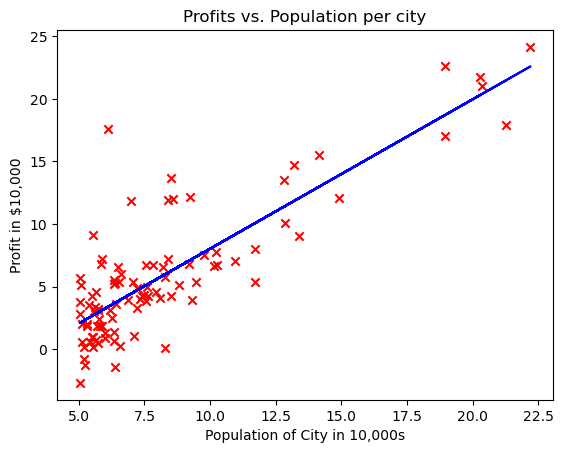

In [39]:
m = x_train.shape[0]
predicted = np.zeros(m)

# calculate the predicted values using the theta parameters found by OLS
'''START CODE HERE '''

for i in range(m):
    predicted[i] = theta[0][0] * 1 + theta[1][0] * x_train[i]

''' END CODE HERE '''

# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')


'''
Compare the difference of predictions between OLS and Gradient Descent.
Why can we get the predictions by OLS directly without iteration?
'''